# Read JSONL + Plot
Simple notebook: load scored JSONL and plot one column.

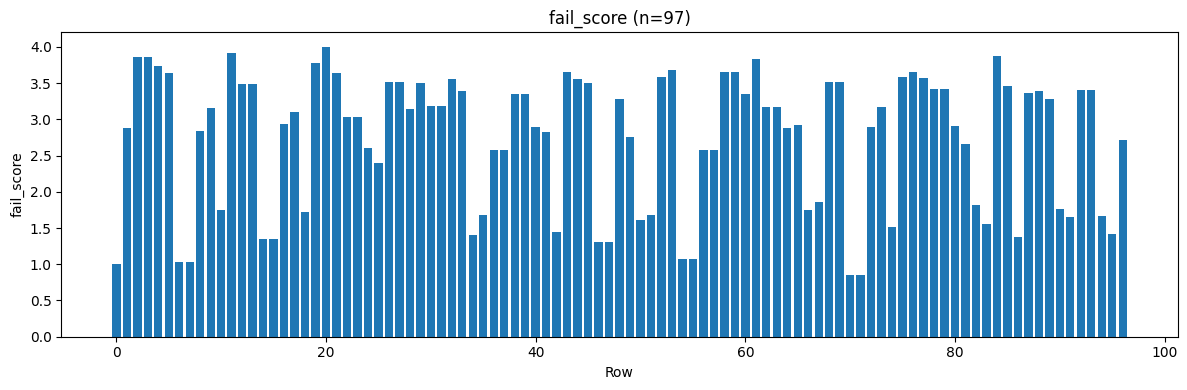

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v2.jsonl")
COL = "fail_score"  # change if needed

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df[COL] = pd.to_numeric(df[COL], errors="coerce")
d = df.dropna(subset=[COL]).reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.bar(range(len(d)), d[COL].to_list())
plt.title(f"{COL} (n={len(d)})")
plt.xlabel("Row")
plt.ylabel(COL)
plt.tight_layout()
plt.show()


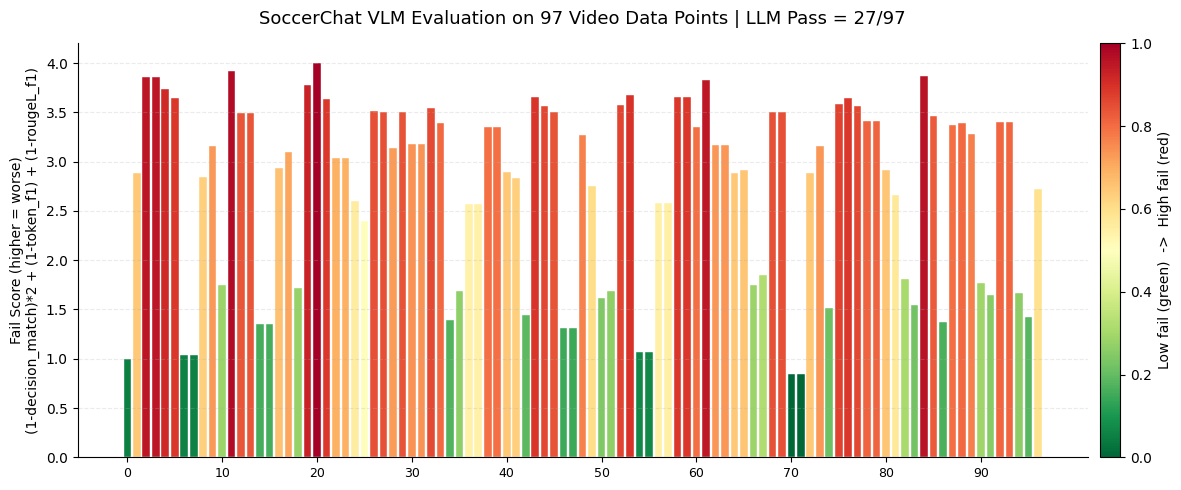

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v2.jsonl")
COL = "fail_score"
rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))
df = pd.DataFrame(rows)
df[COL] = pd.to_numeric(df[COL], errors="coerce")
d = df.dropna(subset=[COL]).reset_index(drop=True)
pass_count = None
if "judge_score_llm" in d.columns:
    j = pd.to_numeric(d["judge_score_llm"], errors="coerce")
    pass_count = int((j == 1).sum())
vals = d[COL].to_numpy()
n = len(vals)
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
den = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / den
colors = plt.cm.RdYlGn_r(norm)
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.3)
title = f"SoccerChat VLM Evaluation on {n} Video Data Points"
if pass_count is not None:
    title += f" | LLM Pass = {pass_count}/{n}"
ax.set_title(title, fontsize=13, pad=14)
ax.set_xlabel(
    "Each bar = one case. decision_match: exact decision correct (0/1); "
    "token_f1: token overlap between prediction and ground truth; "
    "rougeL_f1: sequence-level overlap (longest common subsequence) F1.",
    fontsize=10,
    labelpad=10,
)
ax.set_ylabel(
    "Fail Score (higher = worse)\n"
    "(1-decision_match)*2 + (1-token_f1) + (1-rougeL_f1)",
    fontsize=10,
)
xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")
plt.tight_layout()
plt.show()



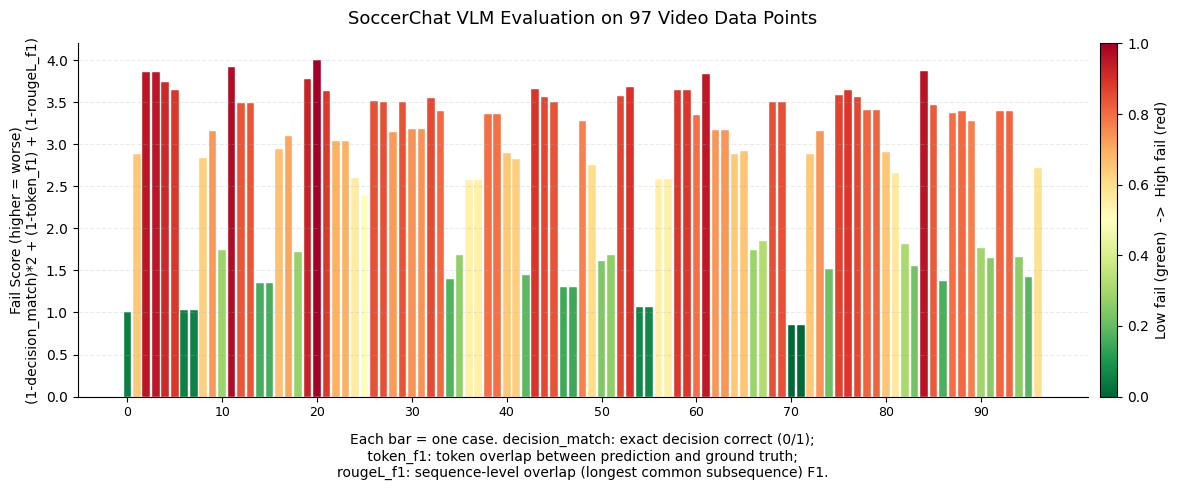

In [3]:
# New cell: updated bottom explanation text
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v2.jsonl")
COL = "fail_score"

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df[COL] = pd.to_numeric(df[COL], errors="coerce")
d = df.dropna(subset=[COL]).reset_index(drop=True)

vals = d[COL].to_numpy()
n = len(vals)
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
denom = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / denom
colors = plt.cm.RdYlGn_r(norm)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.3)

ax.set_title(f"SoccerChat VLM Evaluation on {n} Video Data Points", fontsize=13, pad=14)
ax.set_xlabel(
    "Each bar = one case. decision_match: exact decision correct (0/1);\n "
    "token_f1: token overlap between prediction and ground truth; \n"
    "rougeL_f1: sequence-level overlap (longest common subsequence) F1.",
    fontsize=10,
    labelpad=10,
)
ax.set_ylabel(
    "Fail Score (higher = worse)\n"
    "(1-decision_match)*2 + (1-token_f1) + (1-rougeL_f1)",
    fontsize=10,
)

xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=9)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")

plt.tight_layout()
plt.show()

